In [70]:
import xarray as xr
import numpy as np
import pandas as pd
from scipy import signal as sg
# import time
import os
# import itertools
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from scipy.spatial import cKDTree
import cartopy.feature as cfeature
from sklearn.cluster import DBSCAN
# from scipy.integrate import cumtrapz
import metpy.calc as mpcalc
# from scipy import interpolate
from matplotlib import patches
from scipy.spatial import distance
from scipy.interpolate import splprep, splev
from scipy.ndimage import gaussian_filter
from matplotlib.contour import ContourSet
import scipy
from geopy.distance import geodesic
from collections import defaultdict
# 设置中文
plt.rcParams['font.sans-serif'] = ['SimHei']  # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号

In [2]:
lat_range = (70,-40) 
lon_range = (30, 180)
ds_u = xr.open_dataset('uwnd_850.nc')
ds_v = xr.open_dataset('vwnd_850.nc')

In [3]:
uwnd = ds_u.u.sel(latitude=slice(*lat_range), longitude=slice(*lon_range)).sortby('latitude')
vwnd = ds_v.v.sel(latitude=slice(*lat_range), longitude=slice(*lon_range)).sortby('latitude')
latitude = uwnd.latitude
longitude = uwnd.longitude

In [4]:
# Calculate wind speed
wind_speed = np.sqrt(uwnd**2 + vwnd**2)
smoothed_wind_speed = gaussian_filter(wind_speed, sigma=5)

In [5]:
# Step 2: Gaussian smoothing to remove small disturbances
def smooth_data(data, sigma):
    return gaussian_filter(data, sigma=sigma)

uwnd_smoothed = xr.apply_ufunc(smooth_data, uwnd, kwargs={"sigma": 3})
vwnd_smoothed = xr.apply_ufunc(smooth_data, vwnd, kwargs={"sigma": 3})
# Step 3: Compute wind speed
speed = np.sqrt(uwnd_smoothed**2 + vwnd_smoothed**2)

In [6]:
# Step 4: Rotate wind vectors by 90 degrees to get perpendicular vectors
def rotate_vector_90(u, v):
    u_r = -v  # Rotate u by 90 degrees
    v_r = u   # Rotate v by 90 degrees
    return u_r, v_r

u_r, v_r = rotate_vector_90(uwnd_smoothed, vwnd_smoothed)

In [7]:
# Step 5: Compute advection of speed along the perpendicular vectors
def compute_advection(u_r, v_r, speed, dx, dy):
    # Calculate gradients of wind speed
    d_speed_dx = np.gradient(speed, axis=-1) / dx[:, np.newaxis]
    d_speed_dy = np.gradient(speed, axis=-2) / dy

    # Compute advection
    adv_s = u_r * d_speed_dx + v_r * d_speed_dy
    return adv_s

# Calculate grid spacing (broadcast latitude for dx calculation)
dx = 111e3 * np.cos(np.radians(latitude))  # Convert degrees to meters
dx = dx.values  # Extract numpy array for broadcasting
dy = 111e3
adv_s = compute_advection(u_r, v_r, speed, dx, dy)

In [8]:
# Step 6: Extract jet axis from advection field
def extract_jet_axis(adv_s, speed, u_r, v_r, longitude, latitude, speed_th):
    jet_axis = []
    for i in range(adv_s.shape[0] - 1):
        for j in range(adv_s.shape[1] - 1):
            # Determine the upstream and downstream based on u_r and v_r
            if speed[i, j] >= speed_th:  # Speed threshold filter
                if v_r[i, j] > 0:  # Flow direction indicates positive advection # u_r[i, j] > 0 or v_r[i, j] > 0
                    if adv_s[i, j] > 0 and adv_s[i + 1, j] <= 0:  # Negative to positive transition
                        jet_axis.append((longitude[j].values, latitude[i].values))
                else:
                    if adv_s[i, j] < 0 and adv_s[i + 1, j] >= 0:  # Negative to positive transition
                        # if speed[i, j] >= speed_th:  # Speed threshold filter
                        jet_axis.append((longitude[j].values, latitude[i].values))            
    return np.array(jet_axis)

speed_th = 8  # Wind speed threshold for jet axis
jet_axis_points = extract_jet_axis(adv_s, speed, u_r, v_r, longitude, latitude, speed_th)

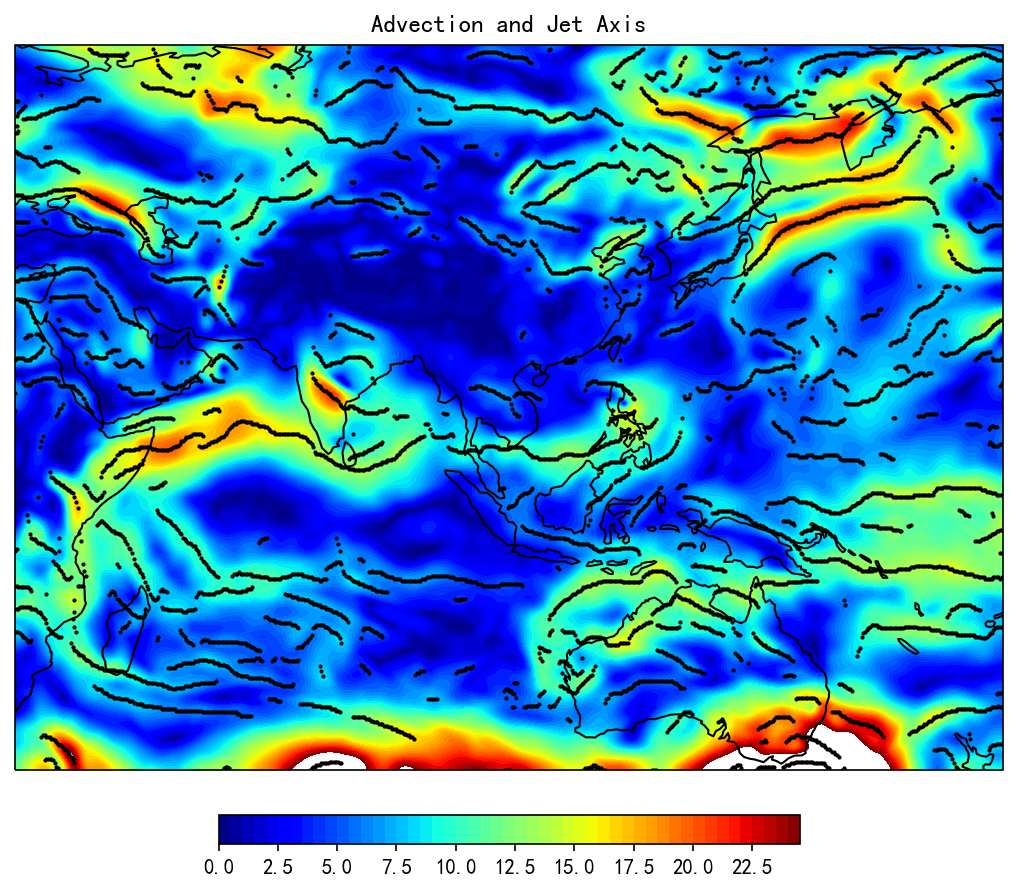

In [9]:
speed_th = 4  # Wind speed threshold for jet axis
jet_axis_points = extract_jet_axis(adv_s, speed, u_r, v_r, longitude, latitude, speed_th)

# Plot results
def plot_jet_axis(adv_s, jet_axis_points, latitude, longitude, title="Advection and Jet Axis"):
    
    fig, ax = plt.subplots(subplot_kw={"projection": ccrs.PlateCarree(),},figsize=(10, 8),dpi=150)
    ax.set_extent([longitude.min(), longitude.max(), latitude.min(), latitude.max()], ccrs.PlateCarree())

    # Add background features
    ax.add_feature(cfeature.COASTLINE)
    # ax.add_feature(cfeature.BORDERS, linestyle=':')
    # 填色绘制wind_speed
    cf = ax.contourf(longitude, latitude, speed, transform=ccrs.PlateCarree(), cmap='jet', levels=np.arange(0, 25, 0.5))
    # 设置cf的colorbar
    cbar = plt.colorbar(cf, ax=ax, shrink=0.5, pad=0.05, orientation='horizontal')
    # # Plot adv_s
    # cf = ax.contourf(longitude, latitude, adv_s, levels=20, cmap='coolwarm', transform=ccrs.PlateCarree())
    # plt.colorbar(cf, ax=ax, orientation='vertical', label='Advection')

    # Overlay jet axis points
    if jet_axis_points.size > 0:
        ax.scatter(jet_axis_points[:, 0], jet_axis_points[:, 1], color='k', s=1, transform=ccrs.PlateCarree(), label='Jet Axis')

    # ax.legend()
    ax.set_title(title)
    plt.show()

plot_jet_axis(adv_s, jet_axis_points, latitude, longitude)

In [10]:
jet_axis_points

array([[ 61.5 , -40.  ],
       [ 74.75, -40.  ],
       [104.25, -40.  ],
       ...,
       [143.75,  69.5 ],
       [ 73.75,  69.75],
       [ 80.75,  69.75]])

In [11]:
def form_lines(points, interval_dis, length_min):
    num_points = len(points)
    visited = np.zeros(num_points, dtype=bool)
    lines = []

    for i in range(num_points):
        if visited[i]:
            continue

        current_line = [points[i]]
        visited[i] = True

        while True:
            dists = distance.cdist([current_line[-1]], points[~visited], metric='euclidean')
            unvisited_indices = np.where(~visited)[0]

            if len(dists[0]) == 0:
                break
            min_dist_idx = np.argmin(dists[0])
            min_dist = dists[0][min_dist_idx]

            if min_dist < interval_dis:
                current_line.append(points[unvisited_indices[min_dist_idx]])
                visited[unvisited_indices[min_dist_idx]] = True
            else:
                break

        total_length = sum(
            np.linalg.norm(np.array(current_line[i]) - np.array(current_line[i + 1]))
            for i in range(len(current_line) - 1)
        )

        if total_length > length_min:
            lines.append(current_line)

    return lines


In [109]:
interval_distance = 2.0#0.6
length_min = 5.0
lines = form_lines(jet_axis_points, interval_distance, length_min)

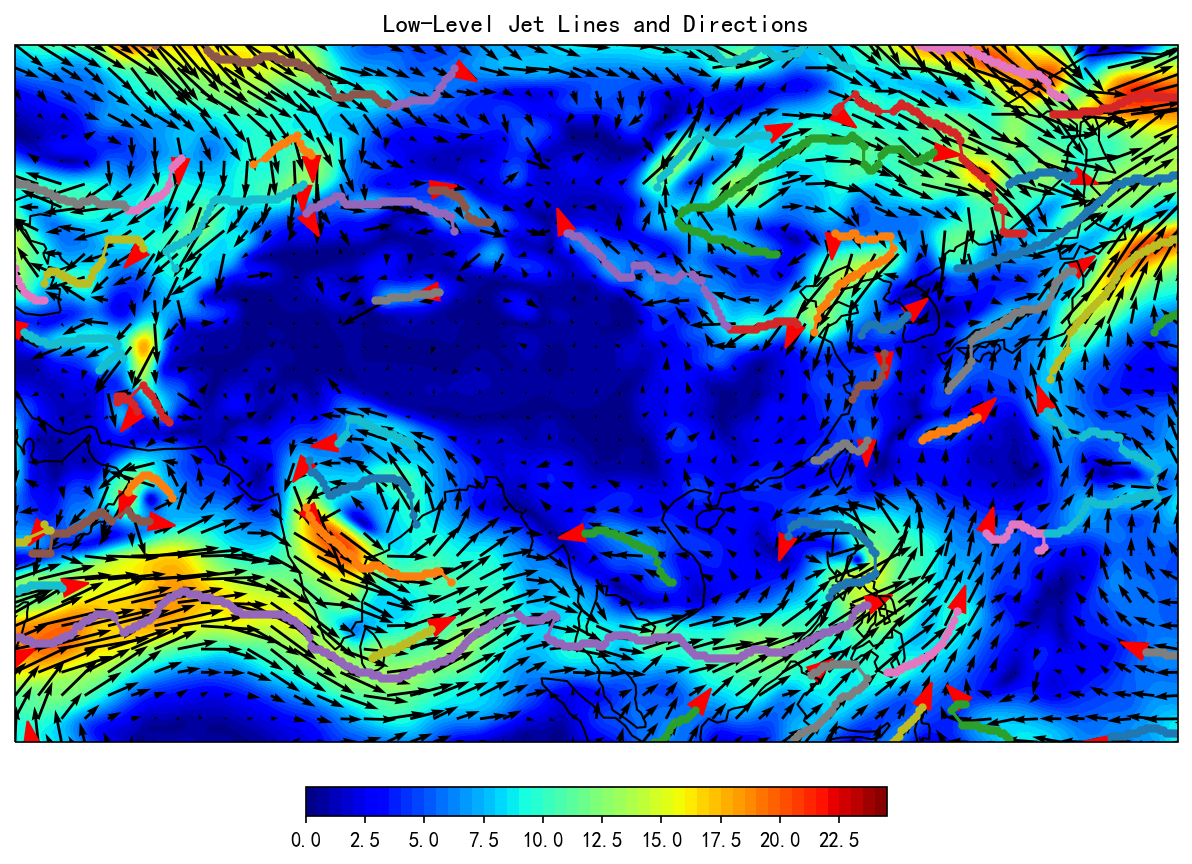

In [149]:
def plot_lines_with_direction(lines, uwnd, vwnd, map_extent=[50, 150, 0, 60], fill=True, same_color=False):
    fig, ax = plt.subplots(subplot_kw={"projection": ccrs.PlateCarree(),},figsize=(10, 8),dpi=150)
    
    ax.set_extent(map_extent, ccrs.PlateCarree())

    # Add background features
    ax.add_feature(cfeature.COASTLINE)
    # ax.add_feature(cfeature.BORDERS, linestyle=':')
    # 填色绘制wind_speed
    if fill:
        cf = ax.contourf(longitude, latitude, speed, transform=ccrs.PlateCarree(), cmap='jet', levels=np.arange(0, 25, 0.5))
        # 设置cf的colorbar
        cbar = plt.colorbar(cf, ax=ax, shrink=0.5, pad=0.05, orientation='horizontal')

    # 添加风向杆图
    skip = 8  # 略过的网格数量
    # ax.barbs(longitude[::skip], latitude[::skip], uwnd[::skip,::skip], vwnd[::skip,::skip], transform=ccrs.PlateCarree(), length=5,barb_increments={'half':2, 'full':4, 'flag':20},sizes={'emptybarb':0})
    # 绘制箭头
    ax.quiver(longitude[::skip], latitude[::skip], uwnd[::skip,::skip], vwnd[::skip,::skip], transform=ccrs.PlateCarree(), scale=300, color='black')

    for line in lines:
        x, y = zip(*line)
        # plt.plot(x, y, marker=".")
        if same_color:
            plt.plot(x, y,  color='red', linewidth=2)
        else:
            plt.plot(x, y, marker=".")
        
        end_point = line[-1]
        end_u = uwnd.sel(latitude=end_point[1], longitude=end_point[0], method="nearest").values
        end_v = vwnd.sel(latitude=end_point[1], longitude=end_point[0], method="nearest").values
        plt.arrow(end_point[0], end_point[1], end_u * 0.01, end_v * 0.01, color="red", head_width=1.5)

    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.title("Low-Level Jet Lines and Directions")
    plt.show()

plot_lines_with_direction(lines, uwnd, vwnd)

In [137]:
def adjust_line_direction(lines, uwnd, vwnd):
    adjusted_lines = []

    for line in lines:
        mid_idx = len(line) // 2
        start, end = line[mid_idx], line[-1]
        vector_line = np.array(end) - np.array(start)

        start_u, start_v = uwnd.sel(latitude=start[1], longitude=start[0], method="nearest").values, \
                           vwnd.sel(latitude=start[1], longitude=start[0], method="nearest").values
        end_u, end_v = uwnd.sel(latitude=end[1], longitude=end[0], method="nearest").values, \
                       vwnd.sel(latitude=end[1], longitude=end[0], method="nearest").values
        vector_wind = np.array([start_u + end_u, start_v + end_v]) / 2

        dot_product = np.dot(vector_line, vector_wind)

        if dot_product < 0:
            adjusted_lines.append(line[::-1])
        else:
            adjusted_lines.append(line)

    return adjusted_lines

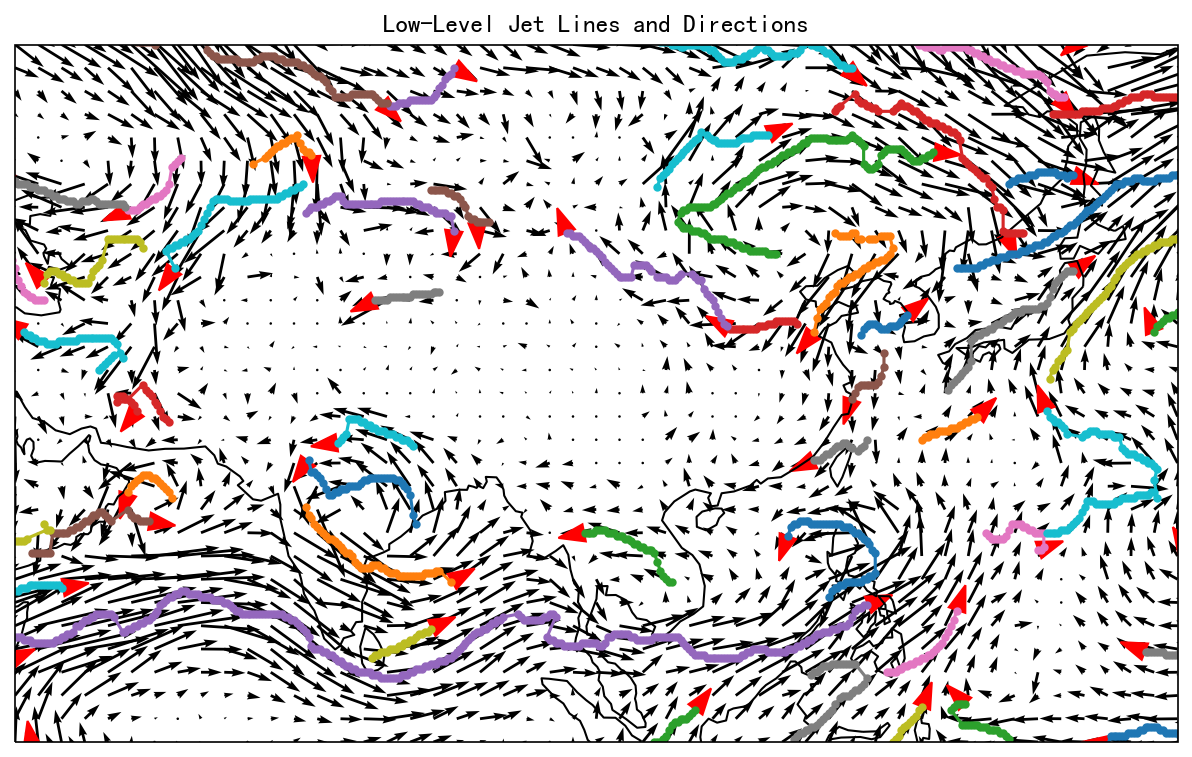

In [152]:
adjusted_lines = adjust_line_direction(lines, uwnd, vwnd)
plot_lines_with_direction(adjusted_lines, uwnd, vwnd, fill=False)

In [131]:
def smooth_lines_Bezier(lines, num_points=100):
    def bezier_curve(points, t):
        n = len(points) - 1
        return sum(
            scipy.special.comb(n, i) * (1 - t)**(n - i) * t**i * np.array(points[i])
            for i in range(n + 1)
        )

    smoothed_lines = []
    t_values = np.linspace(0, 1, num_points)

    for line in lines:
        smoothed_lines.append([bezier_curve(line, t) for t in t_values])

    return smoothed_lines

In [129]:
# Updated function to smooth lines with consistent return structure
def smooth_lines(lines, smoothness=5):
    smoothed_lines = []
    for line in lines:
        line = np.array(line)
        if len(line) > 2:  # Only interpolate lines with more than 2 points
            tck, u = splprep([line[:, 0], line[:, 1]], s=smoothness)  # Longitude, Latitude
            u_new = np.linspace(0, 1, 100)
            smoothed_points = np.array(splev(u_new, tck)).T  # Convert to Nx2 array: [[lon, lat], ...]
            smoothed_lines.append(smoothed_points)
        else:
            # If the line is too short, keep it as it is in the original format
            smoothed_lines.append(line)
    return smoothed_lines

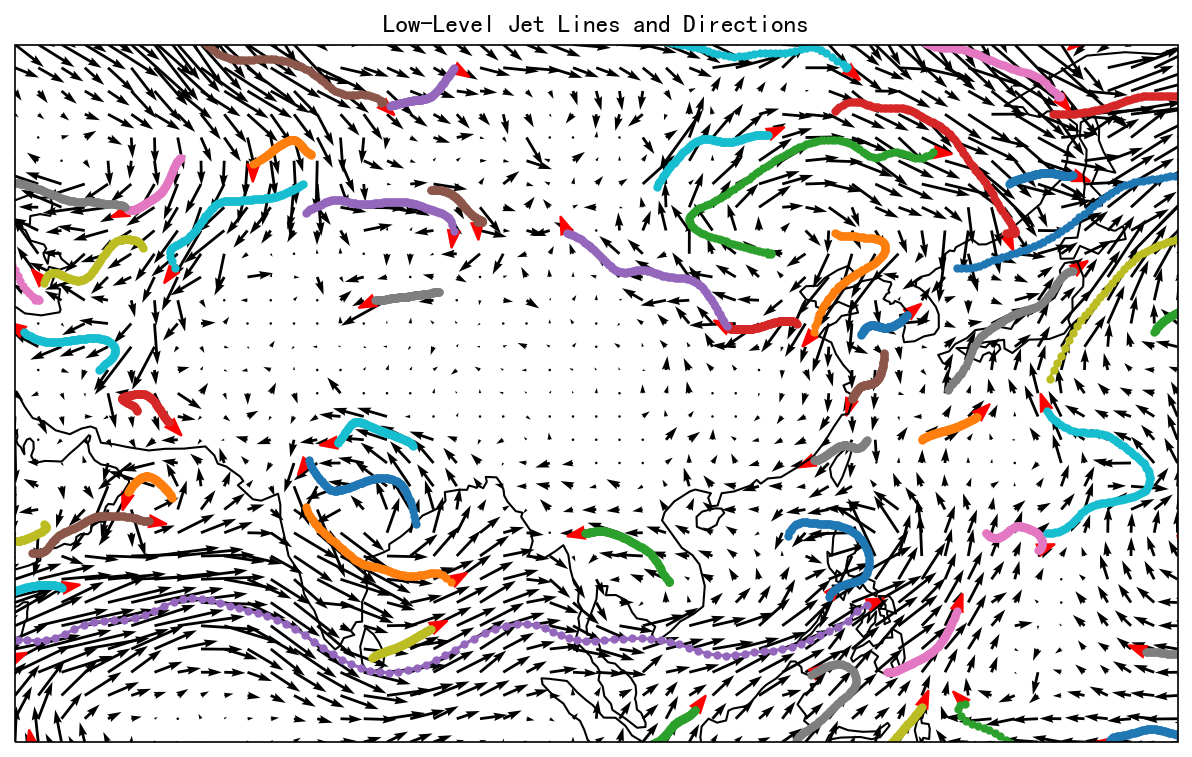

In [134]:
lines_Bezier = smooth_lines_Bezier(adjusted_lines)
plot_lines_with_direction(lines_Bezier, uwnd, vwnd, fill=False)

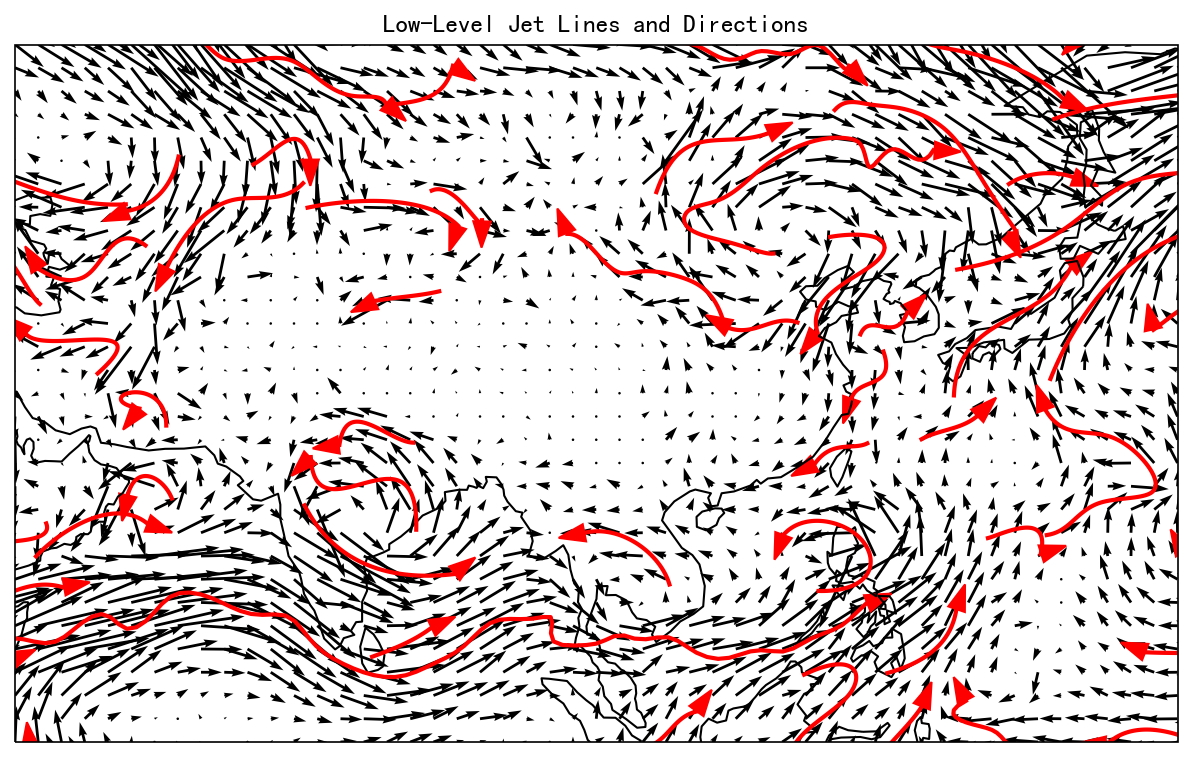

In [154]:
smoothness=5
lines_smooth = smooth_lines(adjusted_lines)
plot_lines_with_direction(lines_smooth, uwnd, vwnd, fill=False, same_color=True)

In [64]:
def merge_lines(adjusted_lines, interval=5):
    # Make a copy of the lines to avoid modifying the original input
    lines = adjusted_lines[:]
    merged = True

    while merged:
        merged = False
        new_lines = []
        used_indices = set()

        for i, line_a in enumerate(lines):
            if i in used_indices:
                continue

            merged_line = line_a
            merged_this_round = False
            closest_line_index = None
            closest_distance = float('inf')

            for j, line_b in enumerate(lines):
                if i == j or j in used_indices:
                    continue

                # Calculate the distance between line_a end and line_b start
                dist_end_start = np.linalg.norm(np.array(line_a[-1]) - np.array(line_b[0]))

                # Find the closest line by end to start points
                if dist_end_start < closest_distance:
                    closest_distance = dist_end_start
                    closest_line_index = j

            # Merge if the closest distance is within the interval
            if closest_line_index is not None and closest_distance < interval:
                line_b = lines[closest_line_index]
                merged_line = merged_line + line_b  # Merge line_a end with line_b start

                used_indices.add(closest_line_index)
                merged_this_round = True

            new_lines.append(merged_line)

            if merged_this_round:
                merged = True

            used_indices.add(i)

        # Remove duplicates and update the lines
        lines = [line for idx, line in enumerate(new_lines) if idx not in used_indices or line]

    return lines

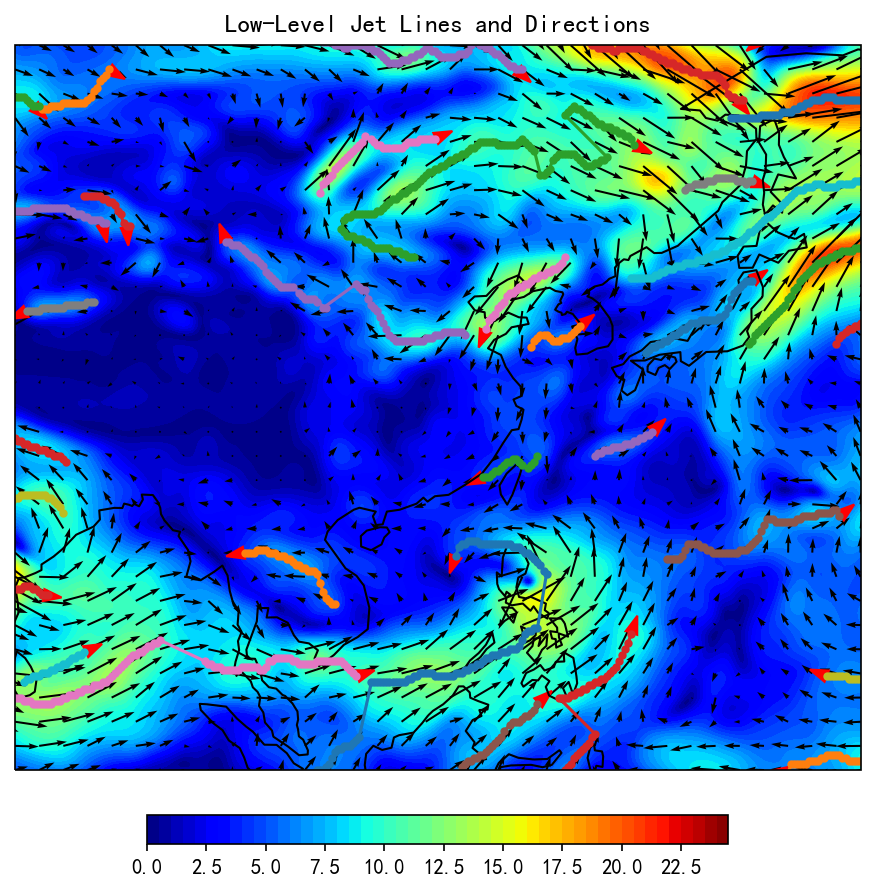

In [65]:
merged_lines = merge_lines(adjusted_lines, interval=5)
plot_lines_with_direction(merged_lines, uwnd, vwnd)

In [98]:
def merge_lines(adjusted_lines, interval=5):
    lines_copy = adjusted_lines.copy()
    start_points = np.array([(line[0][1], line[0][0]) for line in lines_copy])  # Convert to (lat, lon)
    end_points = np.array([(line[-1][1], line[-1][0]) for line in lines_copy])  # Convert to (lat, lon)

    num_lines = len(lines_copy)
    lines_closest_index = np.zeros(num_lines, dtype=int)
    lines_closest_distance = np.full(num_lines, np.inf)

    for i, end_point in enumerate(end_points):
        distances = np.array([geodesic(end_point, sp).kilometers for sp in start_points])
        distances[i] = np.inf  # Ignore self-distance
        min_distance_idx = np.argmin(distances)
        lines_closest_index[i] = min_distance_idx
        lines_closest_distance[i] = distances[min_distance_idx]

    lines_merge_index_info = []


    for current_index in range(num_lines):
        if lines_closest_distance[current_index] < interval*111:
            pair_index = lines_closest_index[current_index]
            found = False

            for merge_group in lines_merge_index_info:
                if current_index in merge_group or pair_index in merge_group:
                    if current_index not in merge_group:
                        #merge_group.insert(0, current_index)
                        merge_group.append(current_index)
                    if pair_index not in merge_group:
                        #merge_group.insert(0, pair_index)
                        merge_group.append(pair_index)
                    found = True
                    break

            if not found:
                #lines_merge_index_info.append([current_index, pair_index])
                lines_merge_index_info.append([pair_index,current_index])
        else:
            found = False
            for merge_group in lines_merge_index_info:
                if current_index in merge_group:
                    found = True
                    break
            if not found:
                lines_merge_index_info.append([current_index])

    # Create merged lines
    merged_indices = set()
    lines_merge = []

    for merge_group in lines_merge_index_info:
        merged_line = []
        for idx in merge_group:
            if idx not in merged_indices:
                merged_line.extend(lines_copy[idx])
                merged_indices.add(idx)
        if len(merged_line) > 0:  # Only add non-empty merged lines
            lines_merge.append(merged_line)

    # # Add remaining unmerged lines
    # for i, line in enumerate(lines_copy):
    #     if i not in merged_indices:
    #         lines_merge.append(line)

    return lines_merge


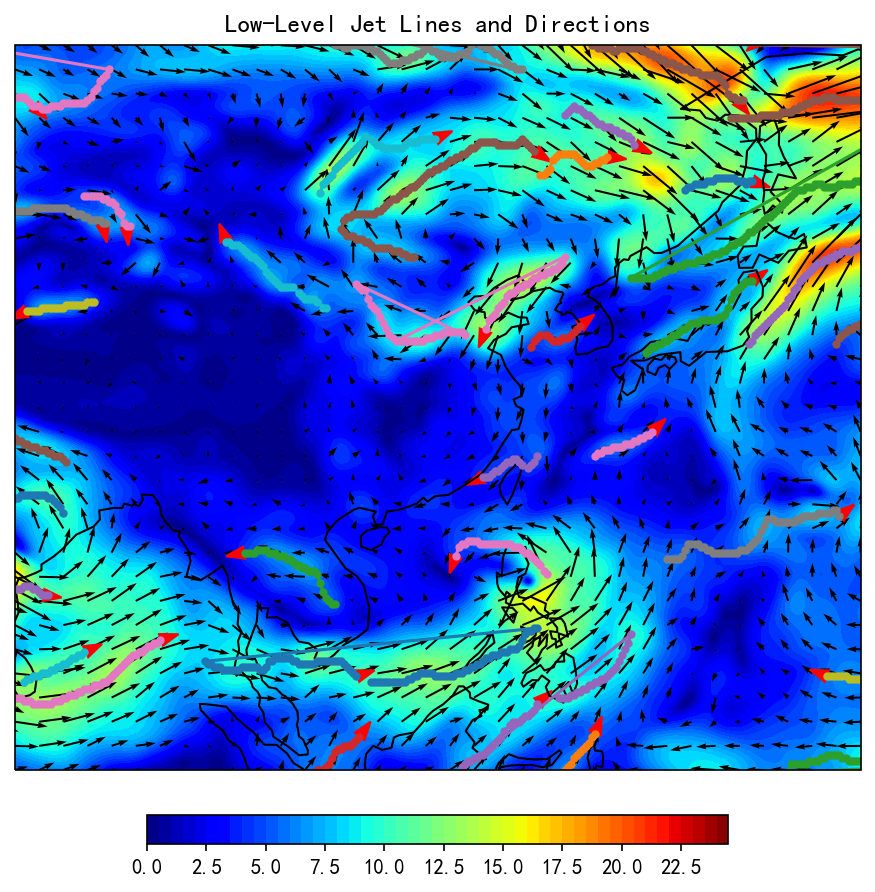

In [99]:
lines_merge = merge_lines(adjusted_lines, interval=2)
plot_lines_with_direction(lines_merge, uwnd, vwnd)

In [87]:
# Output lengths of each merged line
for i, merged_line in enumerate(lines_merge):
    print(f"Line {i + 1} length: {len(merged_line)}")

Line 1 length: 20
Line 2 length: 16
Line 3 length: 29
Line 4 length: 21
Line 5 length: 33
Line 6 length: 63
Line 7 length: 32
Line 8 length: 57
Line 9 length: 16
Line 10 length: 22
Line 11 length: 89
Line 12 length: 49
Line 13 length: 15
Line 14 length: 89
Line 15 length: 69
Line 16 length: 29
Line 17 length: 25
Line 18 length: 37
Line 19 length: 94
Line 20 length: 18
Line 21 length: 29
Line 22 length: 73
Line 23 length: 20
Line 24 length: 21
Line 25 length: 39
Line 26 length: 78
Line 27 length: 21
Line 28 length: 17
Line 29 length: 27
Line 30 length: 36
Line 31 length: 35
Line 32 length: 20
Line 33 length: 92
Line 34 length: 39
Line 35 length: 31
Line 36 length: 38
Line 37 length: 162
Line 38 length: 21
Line 39 length: 72
Line 40 length: 22
Line 41 length: 25
Line 42 length: 19
Line 43 length: 144
Line 44 length: 16
Line 45 length: 51
Line 46 length: 17
Line 47 length: 200
Line 48 length: 18
Line 49 length: 0
Line 50 length: 47
Line 51 length: 21
Line 52 length: 107
Line 53 length: 31

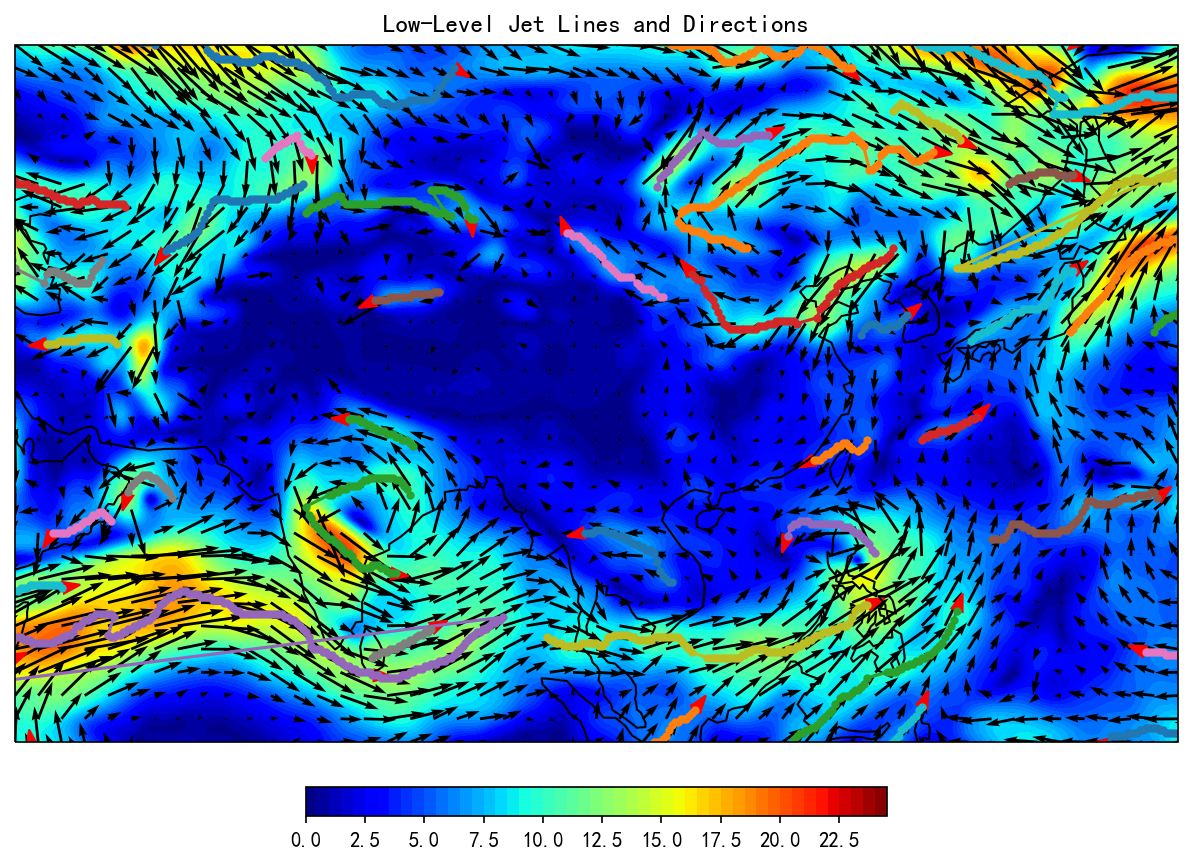

In [107]:
def merge_lines(adjusted_lines, interval=5):
    lines_copy = adjusted_lines.copy()
    start_points = np.array([(line[0][1], line[0][0]) for line in lines_copy])  # Convert to (lat, lon)
    end_points = np.array([(line[-1][1], line[-1][0]) for line in lines_copy])  # Convert to (lat, lon)

    num_lines = len(lines_copy)
    lines_closest_index = np.zeros(num_lines, dtype=int)
    lines_closest_distance = np.full(num_lines, np.inf)

    for i, end_point in enumerate(end_points):
        distances = np.array([geodesic(end_point, sp).kilometers for sp in start_points])
        distances[i] = np.inf  # Ignore self-distance
        min_distance_idx = np.argmin(distances)
        lines_closest_index[i] = min_distance_idx
        lines_closest_distance[i] = distances[min_distance_idx]

    lines_merge_index_info = []


    for current_index in range(num_lines):
        if lines_closest_distance[current_index] < interval*111:
            pair_index = lines_closest_index[current_index]
            found = False

            for merge_group in lines_merge_index_info:
                if current_index in merge_group or pair_index in merge_group:
                    if current_index not in merge_group:
                        merge_group.insert(0, current_index)
                        merge_group.append(current_index)
                    if pair_index not in merge_group:
                        merge_group.insert(0, pair_index)
                        merge_group.append(pair_index)
                    found = True
                    break

            if not found:
                lines_merge_index_info.append([current_index, pair_index])
                #lines_merge_index_info.append([pair_index,current_index])
        else:
            found = False
            for merge_group in lines_merge_index_info:
                if current_index in merge_group:
                    found = True
                    break
            if not found:
                lines_merge_index_info.append([current_index])

    # Create merged lines
    merged_indices = set()
    lines_merge = []

    for merge_group in lines_merge_index_info:
        merged_line = []
        for idx in merge_group:
            if idx not in merged_indices:
                merged_line.extend(lines_copy[idx])
                merged_indices.add(idx)
        if len(merged_line) > 0:  # Only add non-empty merged lines
            lines_merge.append(merged_line)

    # # Add remaining unmerged lines
    # for i, line in enumerate(lines_copy):
    #     if i not in merged_indices:
    #         lines_merge.append(line)

    return lines_merge

lines_merge = merge_lines(adjusted_lines, interval=2.5)
plot_lines_with_direction(lines_merge, uwnd, vwnd)